In [17]:
from pathlib import Path
import scanpy as sc
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [2]:
import sys
sys.path.append(str(Path("../src").resolve()))
from c9_snrnaseq.io_utils import PROJECT_ROOT, load_and_annotate_sheet, save_checkpoint, _stage_header, _log
from c9_snrnaseq.qc_low_quality_cell import (
    compute_qc_metrics,
    detect_low_quality_cells,
    remove_low_quality_cells,
    freeze_raw_counts,
)
from c9_snrnaseq.ambient_rna import (
    estimate_ambient_rna,
    remove_ambient_rna,
)
from c9_snrnaseq.doublets_removal import (
    detect_doublets,
    remove_doublets,
)

from c9_snrnaseq.expression_preprocessing import (
    normalize_counts,
    log_transform,
    select_hvgs,
    scale_expression
)

from c9_snrnaseq.dimensionality_reduction import (
    run_pca,
    build_neighbor_graph,
    run_umap
)

from c9_snrnaseq.annotation import (
    run_leiden_clustering,
    find_cluster_markers
)

from c9_snrnaseq.pipeline import (
    process_one_sample
)

In [3]:
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"
PSEUDOBULK_DIR = RESULTS_DIR / "pseudobulk"
PSEUDOBULK_EXC_DIR = RESULTS_DIR / "pseudobulk_exc_focus"
DE_BROAD_DIR = RESULTS_DIR / "de_pseudobulk_broad"
DE_EXC_DIR = RESULTS_DIR / "de_pseudobulk_exc_focus"

for d in [
    FIGURES_DIR,
    TABLES_DIR,
    PSEUDOBULK_DIR,
    PSEUDOBULK_EXC_DIR,
    DE_BROAD_DIR,
    DE_EXC_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

In [4]:
def process_all_samples_truncated(
    sample_sheet: str | Path = "config/samples.csv",
    processed_dir: str | Path = "data/processed/per_sample",
    merged_output_path: str | Path = "data/processed/merged/merged_after_clustering.h5ad",
    verbose: bool = True,
) -> dict:

    sample_sheet = Path(sample_sheet)
    if not sample_sheet.is_absolute():
        sample_sheet = PROJECT_ROOT / sample_sheet

    processed_dir = Path(processed_dir)
    if not processed_dir.is_absolute():
        processed_dir = PROJECT_ROOT / processed_dir

    merged_output_path = Path(merged_output_path)
    if not merged_output_path.is_absolute():
        merged_output_path = PROJECT_ROOT / merged_output_path

    sample_df = pd.read_csv(sample_sheet)
    cleaned_adatas = []
    cleaned_paths = []

    for _, sample_row in sample_df.iterrows():
        sample_id = str(sample_row["sample_id"])
        sample_dir = processed_dir / sample_id

        matches = sorted(sample_dir.glob("*_after_doublet_removal.h5ad"))
        if not matches:
            raise FileNotFoundError(
                f"No final cleaned checkpoint found for {sample_id} in {sample_dir}"
            )
        if len(matches) > 1:
            raise FileExistsError(
                f"Multiple final cleaned checkpoints found for {sample_id}: {matches}"
            )

        cleaned_path = matches[0]
        cleaned_paths.append(cleaned_path)
        cleaned_adatas.append(sc.read_h5ad(cleaned_path))

    adata_merged = sc.concat(
        cleaned_adatas,
        join="outer",
        label="concat_sample_id",
        keys=[adata.obs["sample"].iloc[0] for adata in cleaned_adatas],
        merge="same",
    )
    adata_merged.obs_names_make_unique()

    adata_merged = normalize_counts(adata_merged)
    adata_merged = log_transform(adata_merged)
    adata_merged = select_hvgs(adata_merged)
    adata_merged = scale_expression(adata_merged)
    adata_merged = run_pca(adata_merged)
    adata_merged = build_neighbor_graph(adata_merged)
    adata_merged = run_umap(adata_merged)
    adata_merged = run_leiden_clustering(adata_merged)
    adata_merged = find_cluster_markers(adata_merged)

    merged_output_path.parent.mkdir(parents=True, exist_ok=True)
    adata_merged.write_h5ad(merged_output_path)

    return {
        "sample_table": sample_df,
        "cleaned_paths": cleaned_paths,
        "adata_merged": adata_merged,
        "merged_output_path": merged_output_path,
    }

In [5]:
result = process_all_samples_truncated(
    sample_sheet="config/samples.csv",
    processed_dir="data/processed/per_sample",
    merged_output_path="data/processed/merged/merged_after_clustering.h5ad",
    verbose=True,
)

/opt/anaconda3/envs/c9_multiomics/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Normalization complete.
Input layer used: raw_counts
Output stored in: adata.layers['normalized_counts']
Target sum per cell: 10000.0
Log transformation complete.
Input layer used: normalized_counts
Output stored in: adata.layers['log1p_normalized_counts']
HVG selection complete.
Input layer used: log1p_normalized_counts
Number of HVGs selected: 2000



/opt/anaconda3/envs/c9_multiomics/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Expression scaling complete.
Input layer used: log1p_normalized_counts
Using HVGs only: True
Number of genes retained: 2000
Scaled matrix stored in adata_scaled.X
PCA complete.
Number of PCs computed: 50
PCA embedding stored in: adata.obsm['X_pca']


/opt/anaconda3/envs/c9_multiomics/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Neighbour graph complete.
n_neighbors used: 15
n_pcs used: 30
Graph stored in: adata.obsp['distances'], adata.obsp['connectivities']
UMAP complete.
UMAP coordinates stored in: adata.obsm['X_umap']


/Users/wangj/Documents/Computational_Biology/Projects/C9_Multiomics/src/c9_snrnaseq/annotation.py:30: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


Leiden clustering complete.
Resolution used: 0.6
Cluster labels stored in: adata.obs['leiden']
Number of clusters detected: 20
Cluster marker detection complete.
Grouping column used: adata.obs['leiden']
Statistical method: wilcoxon
Results stored in: adata.uns['rank_genes_groups']


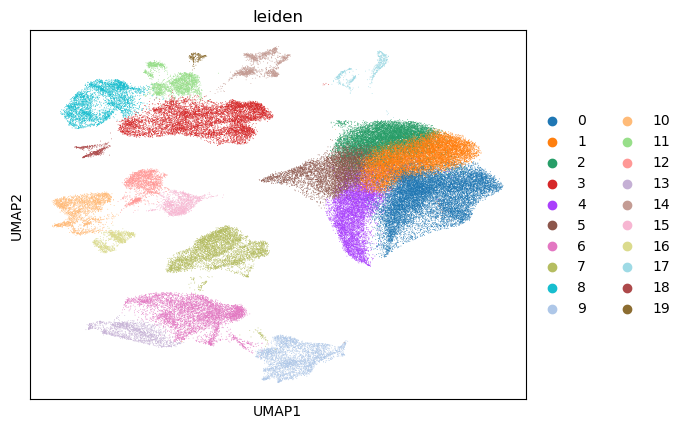

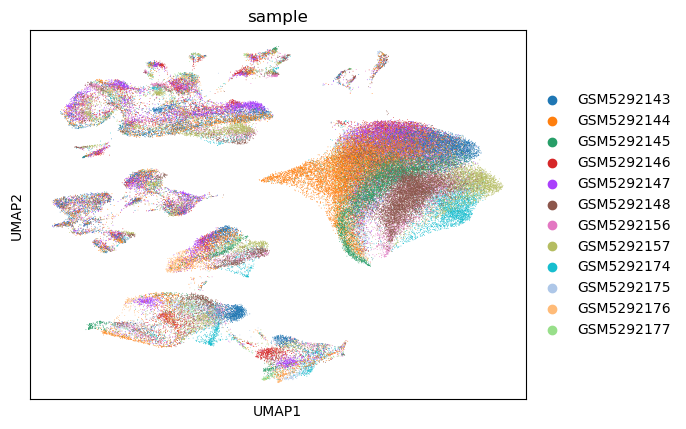

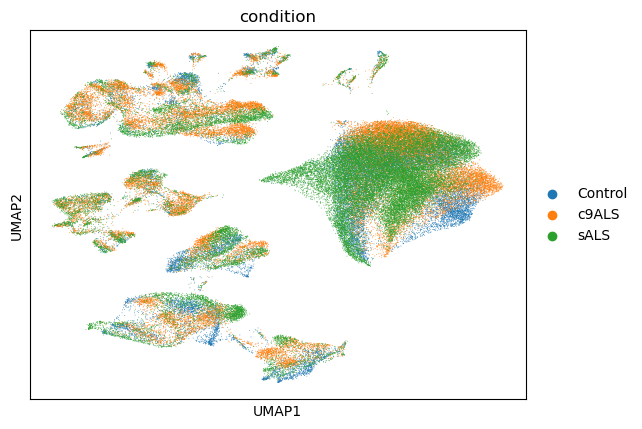

In [7]:
adata_merged = result["adata_merged"]
sc.pl.umap(adata_merged, color="leiden")
sc.pl.umap(adata_merged, color="sample")
sc.pl.umap(adata_merged, color="condition")

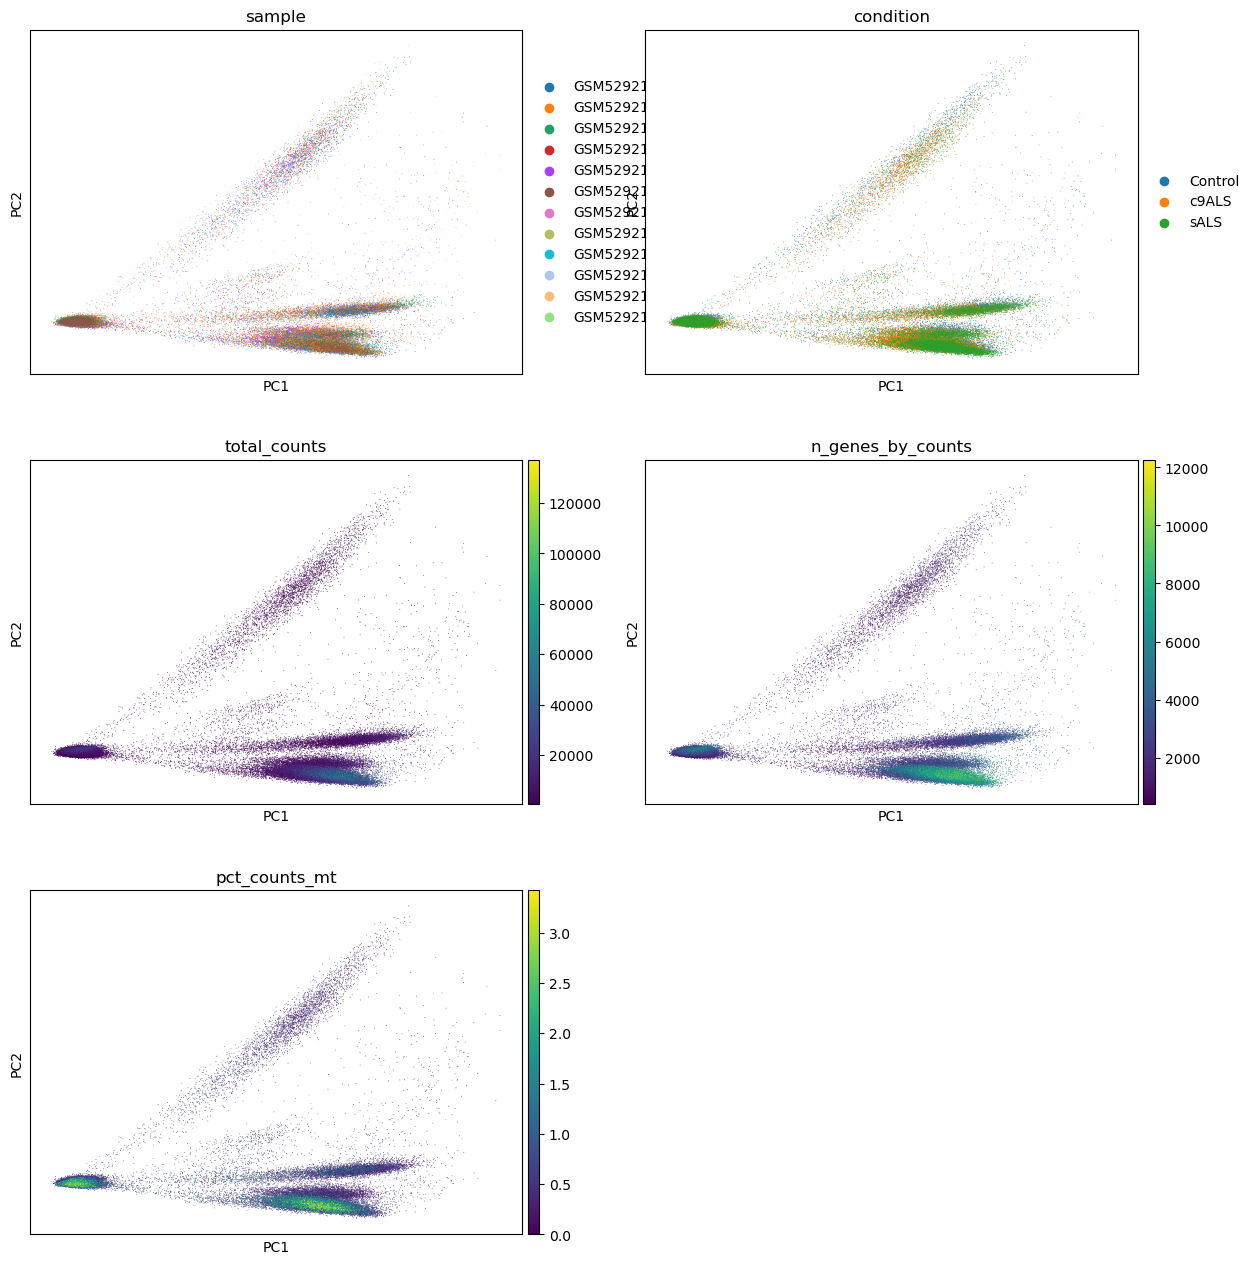

In [ ]:
sc.pl.pca(
    adata_merged,
    color=["sample", "condition", "total_counts", "n_genes_by_counts", "pct_counts_mt"],
    components=["1,2"],
    ncols=2
)

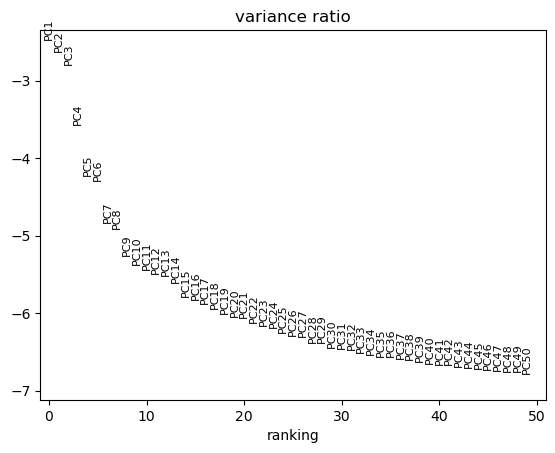

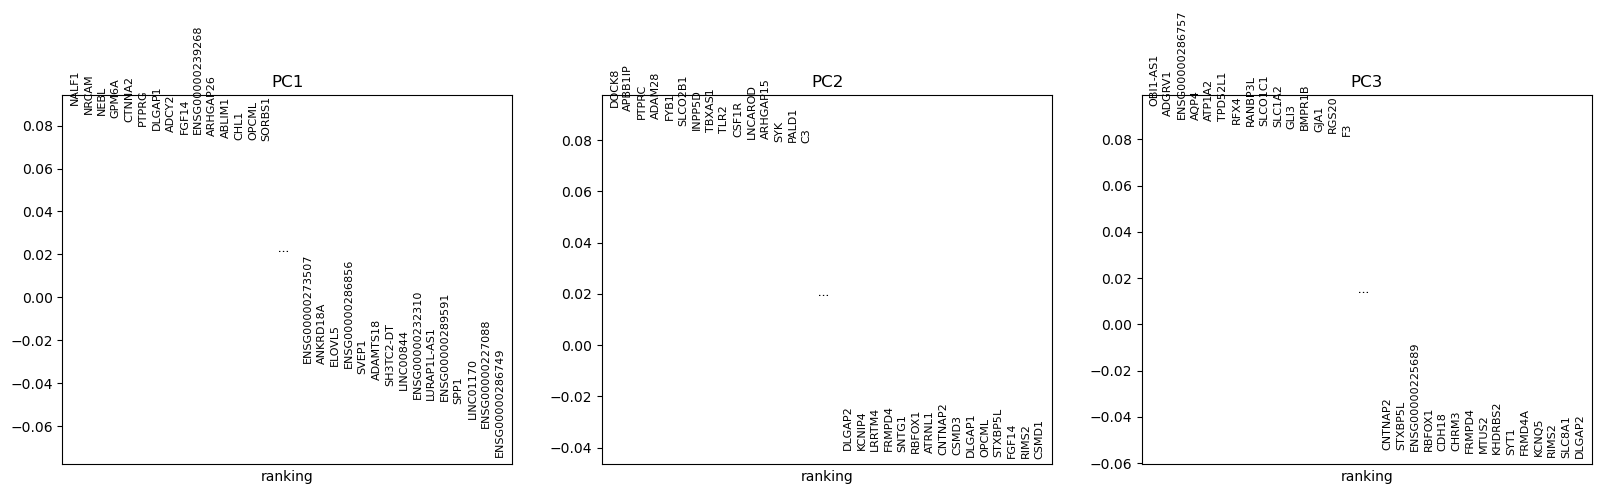

In [9]:
sc.pl.pca_variance_ratio(adata_merged, log=True, n_pcs=50)
sc.pl.pca_loadings(adata_merged, components=[1, 2, 3], include_lowest=True)

In [10]:
pca_df = pd.DataFrame(
    adata_merged.obsm["X_pca"][:, :10],
    index=adata_merged.obs_names,
    columns=[f"PC{i}" for i in range(1, 11)]
)

pca_df = pd.concat([pca_df, adata_merged.obs[["sample", "condition"]]], axis=1)

# mean PC1 by sample
print(pca_df.groupby("sample")["PC1"].mean().sort_values())

# mean PC1 by condition
print(pca_df.groupby("condition")["PC1"].mean().sort_values())

sample
GSM5292145   -4.601880
GSM5292148   -2.966520
GSM5292144   -2.852826
GSM5292175   -0.648749
GSM5292176   -0.247156
GSM5292174   -0.032914
GSM5292156    0.979135
GSM5292177    1.649666
GSM5292146    1.704081
GSM5292147    1.794859
GSM5292157    2.717004
GSM5292143    3.236351
Name: PC1, dtype: float32
condition
sALS      -1.662796
Control   -0.039499
c9ALS      1.833269
Name: PC1, dtype: float32


/var/folders/b0/nvzw55rs7y92rywcfyhwkq_xc2qgzh/T/ipykernel_46296/1363487467.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(pca_df.groupby("sample")["PC1"].mean().sort_values())
/var/folders/b0/nvzw55rs7y92rywcfyhwkq_xc2qgzh/T/ipykernel_46296/1363487467.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(pca_df.groupby("condition")["PC1"].mean().sort_values())


## Harmony Integration And Broad Cell-Class Annotation

2026-04-07 13:25:40,747 - harmonypy - INFO - Running Harmony (PyTorch on mps)
2026-04-07 13:25:40,749 - harmonypy - INFO -   Parameters:
2026-04-07 13:25:40,749 - harmonypy - INFO -     max_iter_harmony: 10
2026-04-07 13:25:40,749 - harmonypy - INFO -     max_iter_kmeans: 20
2026-04-07 13:25:40,750 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-04-07 13:25:40,750 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-04-07 13:25:40,750 - harmonypy - INFO -     nclust: 100
2026-04-07 13:25:40,750 - harmonypy - INFO -     block_size: 0.05
2026-04-07 13:25:40,752 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
2026-04-07 13:25:40,753 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-04-07 13:25:40,753 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-04-07 13:25:40,753 - harmonypy - INFO -     verbose: True
2026-04-07 13:25:40,753 - harmonypy - INFO -     random_state: 0
2026-04-07 13:25:40,754 - harmonypy - INFO -   Data: 50 

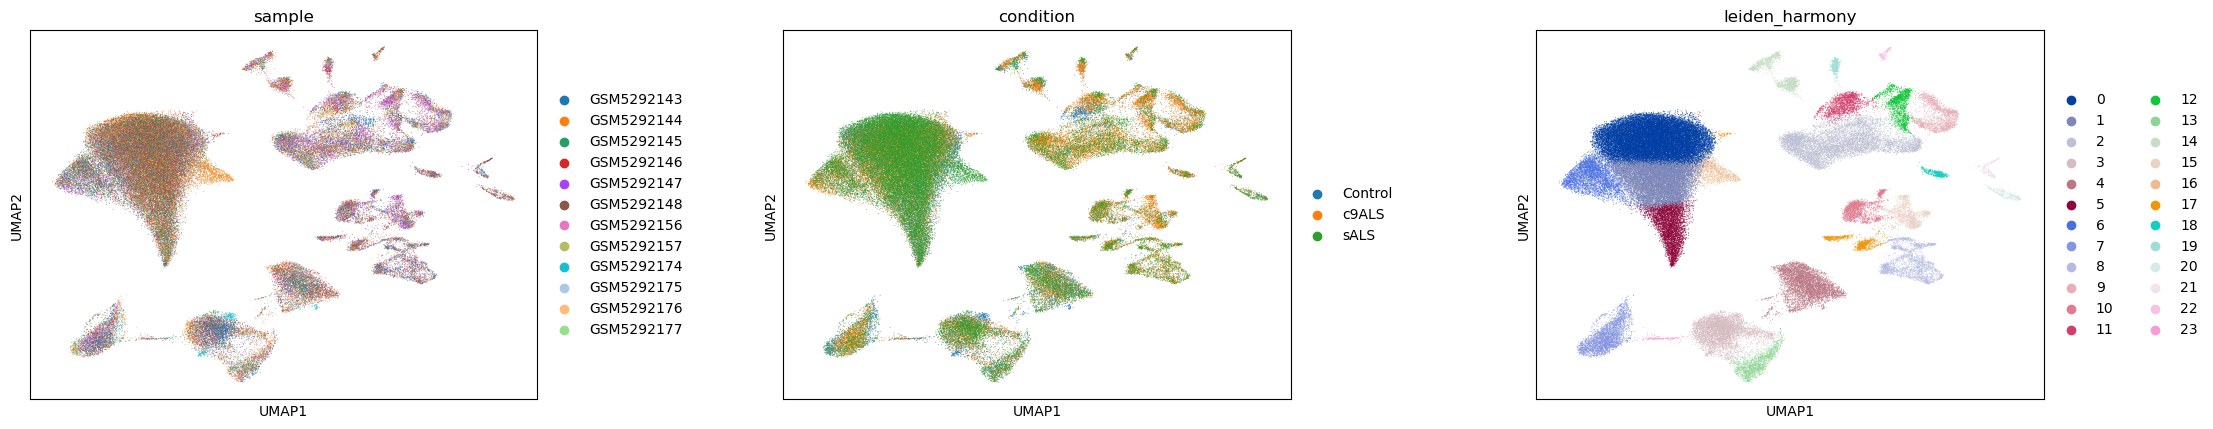

In [13]:
import harmonypy as hm

adata_hm = adata_merged.copy()

# Harmony on existing PCA
X = adata_hm.obsm["X_pca"].astype("float64")
ho = hm.run_harmony(X, adata_hm.obs, vars_use="sample")

Z = ho.Z_corr
if Z.shape != X.shape:
    Z = Z.T

adata_hm.obsm["X_pca_harmony"] = Z

# Build graph and embedding from Harmony PCs
sc.pp.neighbors(adata_hm, use_rep="X_pca_harmony")
sc.tl.umap(adata_hm, random_state=0)
sc.tl.leiden(adata_hm, resolution=0.6, key_added="leiden_harmony")

# Plot
sc.pl.umap(adata_hm, color=["sample", "condition", "leiden_harmony"], wspace=0.35)

In [ ]:
hm_ckpt = PROJECT_ROOT / "data/processed/merged/adata_hm_after_harmony.h5ad"
hm_ckpt.parent.mkdir(parents=True, exist_ok=True)

adata_hm.write_h5ad(hm_ckpt)

print(f"Saved Harmony-integrated object to: {hm_ckpt}")
print(adata_hm.shape)
print("Has X_pca_harmony:", "X_pca_harmony" in adata_hm.obsm)
print("Has leiden_harmony:", "leiden_harmony" in adata_hm.obs.columns)

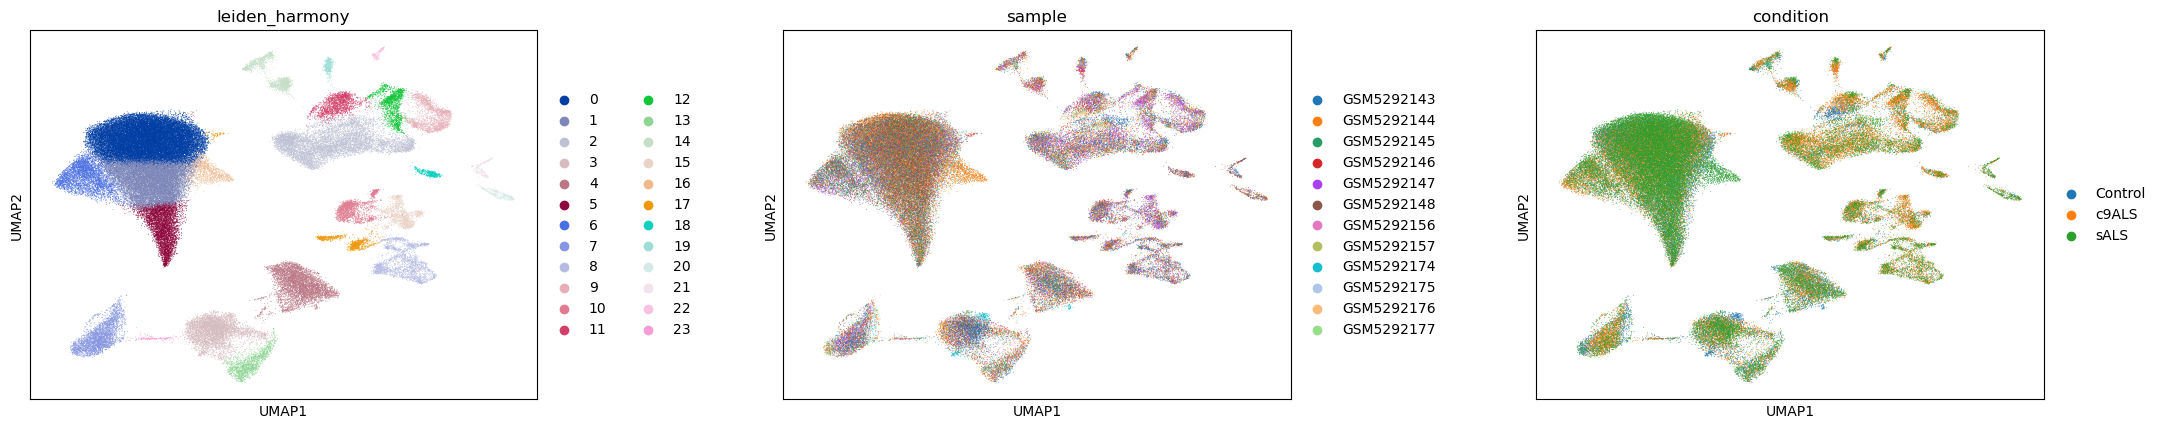

In [14]:
sc.pl.umap(
    adata_hm,
    color=["leiden_harmony", "sample", "condition"],
    wspace=0.35,
)

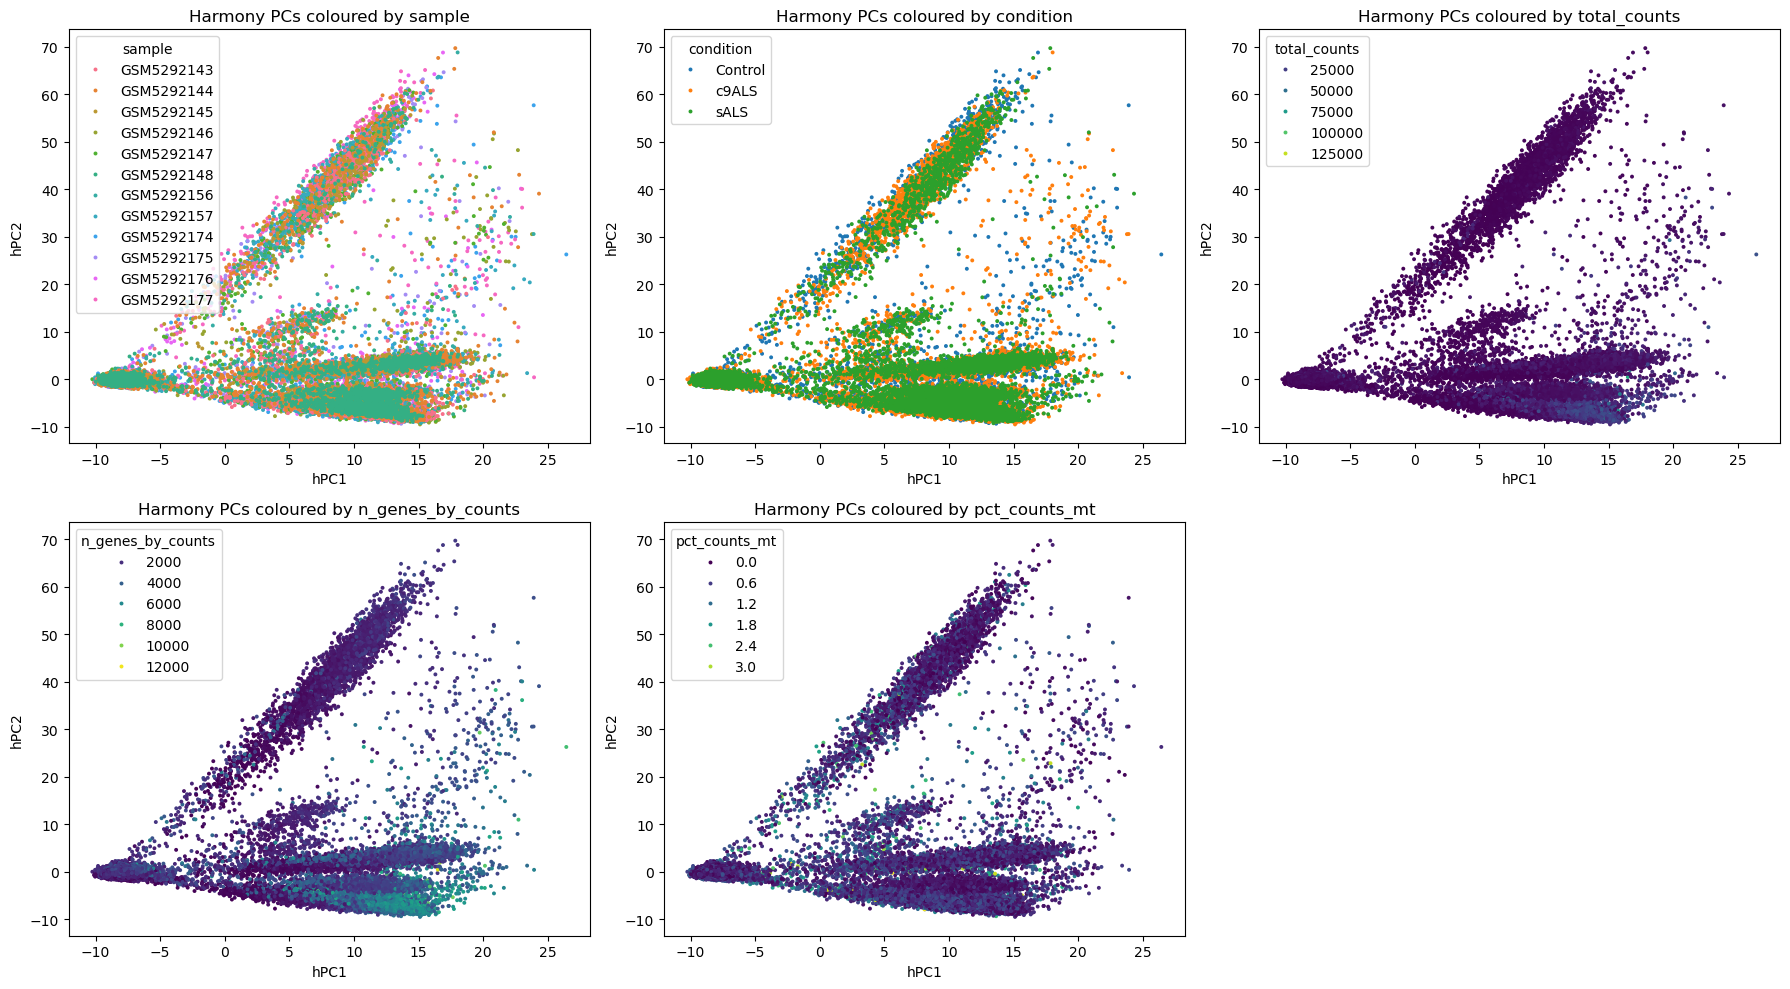

In [18]:
hm_df = pd.DataFrame(
    adata_hm.obsm["X_pca_harmony"][:, :2],
    index=adata_hm.obs_names,
    columns=["hPC1", "hPC2"],
).join(adata_hm.obs[["sample", "condition", "total_counts", "n_genes_by_counts", "pct_counts_mt"]])

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(
    axes.flatten(),
    ["sample", "condition", "total_counts", "n_genes_by_counts", "pct_counts_mt"]
):
    sns.scatterplot(
        data=hm_df,
        x="hPC1",
        y="hPC2",
        hue=col,
        palette="viridis" if col not in ["sample", "condition"] else None,
        s=8,
        linewidth=0,
        ax=ax
    )
    ax.set_title(f"Harmony PCs coloured by {col}")

axes.flatten()[-1].axis("off")
plt.tight_layout()
plt.show()


In [19]:
hm_pc_df = pd.DataFrame(
    adata_hm.obsm["X_pca_harmony"][:, :10],
    index=adata_hm.obs_names,
    columns=[f"hPC{i}" for i in range(1, 11)],
)

hm_pc_df = pd.concat([hm_pc_df, adata_hm.obs[["sample", "condition"]]], axis=1)

print("Mean hPC1 by sample")
display(hm_pc_df.groupby("sample")["hPC1"].mean().sort_values())

print("Mean hPC1 by condition")
display(hm_pc_df.groupby("condition")["hPC1"].mean().sort_values())

print("Mean hPC2 by sample")
display(hm_pc_df.groupby("sample")["hPC2"].mean().sort_values())

print("Mean hPC2 by condition")
display(hm_pc_df.groupby("condition")["hPC2"].mean().sort_values())

Mean hPC1 by sample


/var/folders/b0/nvzw55rs7y92rywcfyhwkq_xc2qgzh/T/ipykernel_46296/82109167.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(hm_pc_df.groupby("sample")["hPC1"].mean().sort_values())


sample
GSM5292145   -4.890409
GSM5292148   -3.087696
GSM5292144   -2.753648
GSM5292175   -0.561543
GSM5292176   -0.429866
GSM5292174    0.035065
GSM5292156    1.139804
GSM5292177    1.466300
GSM5292146    2.167248
GSM5292147    2.213807
GSM5292157    3.089889
GSM5292143    3.112265
Name: hPC1, dtype: float32

Mean hPC1 by condition


/var/folders/b0/nvzw55rs7y92rywcfyhwkq_xc2qgzh/T/ipykernel_46296/82109167.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(hm_pc_df.groupby("condition")["hPC1"].mean().sort_values())


...

/var/folders/b0/nvzw55rs7y92rywcfyhwkq_xc2qgzh/T/ipykernel_46296/82109167.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(hm_pc_df.groupby("sample")["hPC2"].mean().sort_values())


sample
GSM5292157   -1.057256
GSM5292147   -0.888474
GSM5292143   -0.594171
GSM5292156   -0.278483
GSM5292148   -0.243681
GSM5292176   -0.229525
GSM5292144   -0.193609
GSM5292146    0.411730
GSM5292175    0.826907
GSM5292145    0.839424
GSM5292174    1.742426
GSM5292177    1.893526
Name: hPC2, dtype: float32

Mean hPC2 by condition


/var/folders/b0/nvzw55rs7y92rywcfyhwkq_xc2qgzh/T/ipykernel_46296/82109167.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(hm_pc_df.groupby("condition")["hPC2"].mean().sort_values())


condition
c9ALS     -0.468023
sALS      -0.153084
Control    0.928689
Name: hPC2, dtype: float32